***
# <font color=green size=10>CURSO DE ESTATÍSTICA - PARTE 1</font>
***

## Trabalho de Análise Descritiva de um Conjunto de Dados

Utilizando os conhecimentos adquiridos em nosso treinamento realize uma análise descritiva básica de um conjunto de dados retirados da Pesquisa Nacional por Amostra de Domicílios - 2015 do IBGE.

Vamos construir histogramas, calcular e avaliar medidas de tendência central, medidas separatrizes e de dispersão dos dados.

Siga o roteiro proposto e vá completando as células vazias. Procure pensar em mais informações interessantes que podem ser exploradas em nosso dataset.

# <font color=green>DATASET DO PROJETO</font>
***

### Pesquisa Nacional por Amostra de Domicílios - 2015

A <b>Pesquisa Nacional por Amostra de Domicílios - PNAD</b> investiga anualmente, de forma permanente, características gerais da população, de educação, trabalho, rendimento e habitação e outras, com periodicidade variável, de acordo com as necessidades de informação para o país, como as características sobre migração, fecundidade, nupcialidade, saúde, segurança alimentar, entre outros temas. O levantamento dessas estatísticas constitui, ao longo dos 49 anos de realização da pesquisa, um importante instrumento para formulação, validação e avaliação de políticas orientadas para o desenvolvimento socioeconômico e a melhoria das condições de vida no Brasil.

### Fonte dos Dados

https://ww2.ibge.gov.br/home/estatistica/populacao/trabalhoerendimento/pnad2015/microdados.shtm

### Variáveis utilizadas

> ### Renda
> ***

Rendimento mensal do trabalho principal para pessoas de 10 anos ou mais de idade.

> ### Idade
> ***

Idade do morador na data de referência em anos.

> ### Altura (elaboração própria)
> ***

Altura do morador em metros.

> ### UF
> ***

|Código|Descrição|
|---|---|
|11|Rondônia|
|12|Acre|
|13|Amazonas|
|14|Roraima|
|15|Pará|
|16|Amapá|
|17|Tocantins|
|21|Maranhão|
|22|Piauí|
|23|Ceará|
|24|Rio Grande do Norte|
|25|Paraíba|
|26|Pernambuco|
|27|Alagoas|
|28|Sergipe|
|29|Bahia|
|31|Minas Gerais|
|32|Espírito Santo|
|33|Rio de Janeiro|
|35|São Paulo|
|41|Paraná|
|42|Santa Catarina|
|43|Rio Grande do Sul|
|50|Mato Grosso do Sul|
|51|Mato Grosso|
|52|Goiás|
|53|Distrito Federal|

> ### Sexo
> ***

|Código|Descrição|
|---|---|
|0|Masculino|
|1|Feminino|

> ### Anos de Estudo
> ***

|Código|Descrição|
|---|---|
|1|Sem instrução e menos de 1 ano|
|2|1 ano|
|3|2 anos|
|4|3 anos|
|5|4 anos|
|6|5 anos|
|7|6 anos|
|8|7 anos|
|9|8 anos|
|10|9 anos|
|11|10 anos|
|12|11 anos|
|13|12 anos|
|14|13 anos|
|15|14 anos|
|16|15 anos ou mais|
|17|Não determinados|
||Não aplicável|

> ### Cor
> ***

|Código|Descrição|
|---|---|
|0|Indígena|
|2|Branca|
|4|Preta|
|6|Amarela|
|8|Parda|
|9|Sem declaração|

#### <font color='red'>Observação</font>
***
> Os seguintes tratamentos foram realizados nos dados originais:
> 1. Foram eliminados os registros onde a <b>Renda</b> era inválida (999 999 999 999);
> 2. Foram eliminados os registros onde a <b>Renda</b> era missing;
> 3. Foram considerados somente os registros das <b>Pessoas de Referência</b> de cada domicílio (responsável pelo domicílio).

***
***

### Utilize a célula abaixo para importar as biblioteca que precisar para executar as tarefas
#### <font color='red'>Sugestões: pandas, numpy, seaborn</font>

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns

### Importe o dataset e armazene o conteúdo em uma DataFrame

In [9]:
df = pd.read_csv('dados.csv')

### Visualize o conteúdo do DataFrame

In [10]:
df.head(10)

,UF,Sexo,Idade,Cor,Anos de Estudo,Renda,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631
5,11,1,34,8,12,790,1.637906
6,11,0,57,8,12,3150,1.570078
7,11,1,60,8,12,1700,1.608495
8,11,1,50,4,14,1800,1.780329
9,11,0,26,8,12,1150,1.793203


### Para avaliarmos o comportamento da variável RENDA vamos construir uma tabela de frequências considerando as seguintes classes em salários mínimos (SM)
#### <font color='blue'>Descreva os pontos mais relevantes que você observa na tabela e no gráfico.</font>

Classes de renda:

<b>A</b> ► Acima de 25 SM

<b>B</b> ► De 15 a 25 SM

<b>C</b> ► De 5 a 15 SM

<b>D</b> ► De 2 a 5 SM

<b>E</b> ► Até 2 SM

Para construir as classes de renda considere que o salário mínimo na época da pesquisa era de <b>R$ 788,00</b>.

#### Siga os passos abaixo:

### 1º Definir os intevalos das classes em reais (R$)

In [11]:
df_Renda = df['Renda'].apply(lambda x: f'R$ {x:,.2f}'.replace(',', 'v').replace('.', ',').replace('v', '.'))
print(df_Renda)

0          R$ 800,00
1        R$ 1.150,00
2          R$ 880,00
3        R$ 3.500,00
4          R$ 150,00
            ...     
76835      R$ 812,00
76836    R$ 1.500,00
76837    R$ 1.300,00
76838    R$ 1.500,00
76839      R$ 900,00
Name: Renda, Length: 76840, dtype: object


In [12]:
df['Renda'] = (
    df['Renda']
    .astype(str)
    .str.replace('R$', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

### 2º Definir os labels das classes

In [25]:
labels = ['E', 'D', 'C', 'B', 'A']
labels = sorted(labels, reverse=False)
print(labels)

['A', 'B', 'C', 'D', 'E']


In [26]:
classes = [
    df.Renda.min(),
    2000,
    4000,
    6000,
    8000,
    df.Renda.max()
]

### 3º Construir a coluna de frequências

In [27]:
frequencia = pd.cut(df.Renda, bins=classes, labels=labels, include_lowest=True)
frequencia = frequencia.value_counts()
frequencia

,count
Renda,
A,58474
B,11325
C,3394
E,2274
D,1373


### 4º Construir a coluna de percentuais

In [28]:
percentual = frequencia / frequencia.sum() * 100
percentual

,count
Renda,
A,76.098386
B,14.738417
C,4.416970
E,2.959396
D,1.786830


### 5º Juntar as colunas de frequência e percentuais e ordenar as linhas de acordo com os labels das classes

In [29]:
dist_freq_renda = pd.DataFrame({'Frequência': frequencia, 'Porcentagem (%)': percentual})
dist_freq_renda.sort_index(ascending=False, inplace=True)
dist_freq_renda

,Frequência,Porcentagem (%)
Renda,,
E,2274,2.959396
D,1373,1.786830
C,3394,4.416970
B,11325,14.738417
A,58474,76.098386


### Construa um gráfico de barras para visualizar as informações da tabela de frequências acima

In [30]:
df_sorted = df.sort_values('Renda', ascending=False)

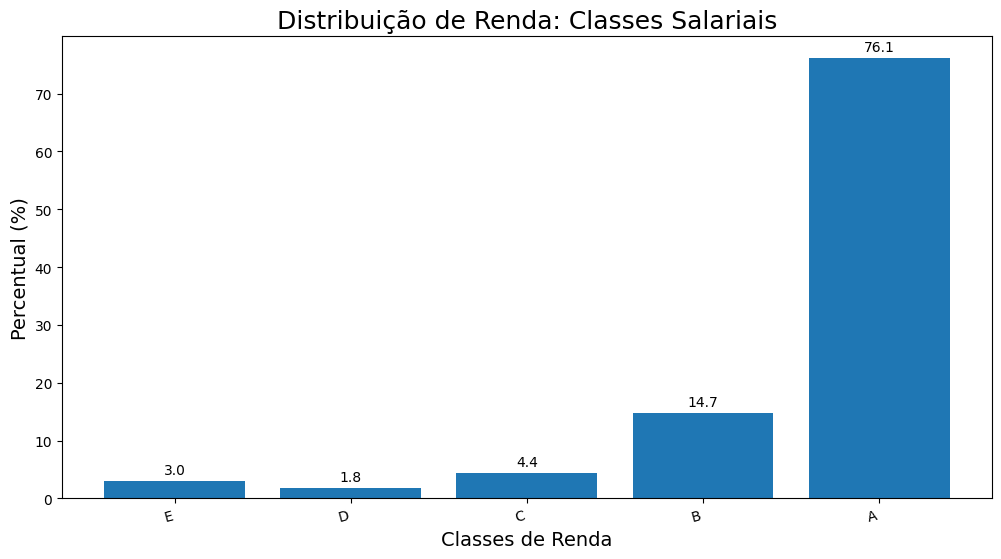

In [33]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 6))
barras = ax.bar(dist_freq_renda.index, dist_freq_renda['Porcentagem (%)'])
ax.bar_label(barras, padding=3, fmt='%.1f')
plt.title('Distribuição de Renda: Classes Salariais', fontsize=18)
plt.xlabel('Classes de Renda', fontsize=14)
plt.setp(ax.get_xticklabels(), rotation=15, horizontalalignment='right')
plt.ylabel('Percentual (%)', fontsize=14)
plt.show()

> ### Conclusões

Escreva suas conclusões aqui...

Analíses simples no ínicio parecem complicadas mas com o tempo vamos pegando o jeito de fazer os gráficos e plotar os resultados

### Crie um histograma para as variáveis QUANTITATIVAS de nosso dataset
#### <font color='blue'>Descreva os pontos mais relevantes que você observa nos gráficos (assimetrias e seus tipos, possíveis causas para determinados comportamentos etc.)</font>

Text(0.5, 1.0, 'Distribuição de Renda')

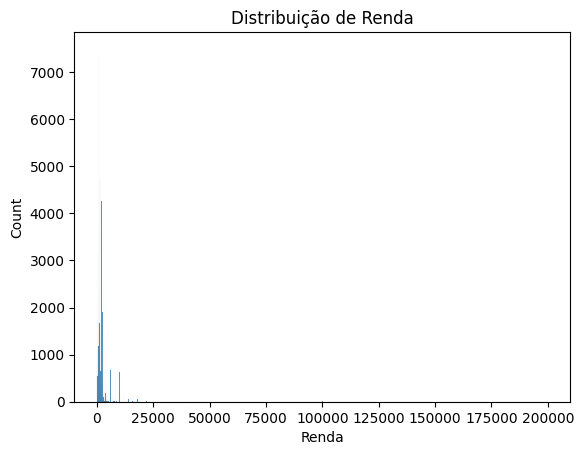

In [34]:
histograma = sns.histplot(data=df, x='Renda').set_title('Distribuição de Renda')
histograma

<Axes: xlabel='Altura', ylabel='Count'>

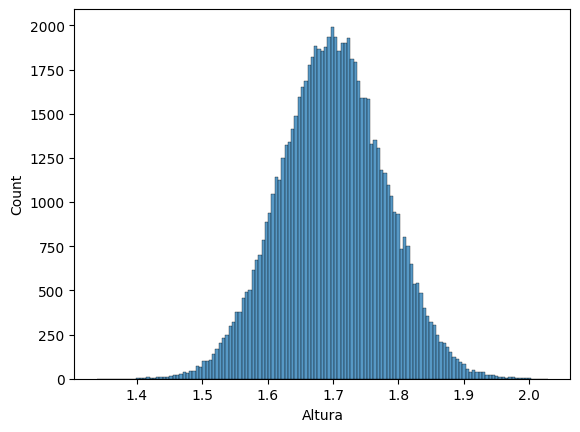

In [35]:
histograma = sns.histplot(data=df, x='Altura')
histograma

<Axes: xlabel='Idade', ylabel='Count'>

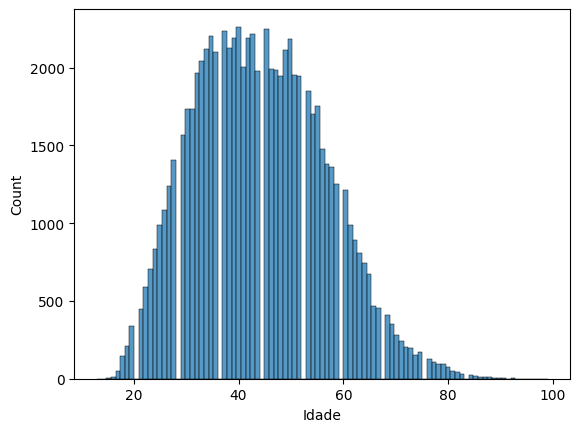

In [36]:
histograma = sns.histplot(data=df, x='Idade')
histograma

> ### Conclusões

Escreva suas conclusões aqui...

### Para a variável RENDA, construa um histograma somente com as informações das pessoas com rendimento até R$ 20.000,00

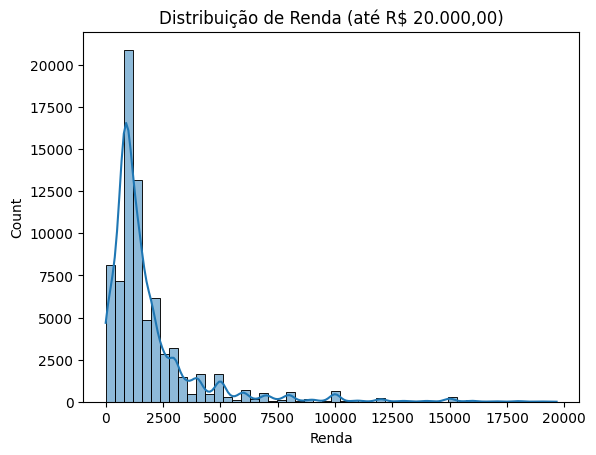

In [37]:
import matplotlib.pyplot as plt
df_filtered = df.query('Renda < 20000')
ax = sns.histplot(data=df_filtered, x='Renda', kde=True, bins=50)
ax.set_title('Distribuição de Renda (até R$ 20.000,00)')
plt.show()

### Construa uma tabela de frequências e uma com os percentuais do cruzando das variáveis SEXO e COR
#### <font color='blue'>Avalie o resultado da tabela e escreva suas principais conclusões</font>
#### <font color='red'>Utilize os dicionários abaixo para renomear as linha e colunas das tabelas de frequências e dos gráficos em nosso projeto</font>

In [38]:
sexo = {
    0: 'Masculino',
    1: 'Feminino'
}
cor = {
    0: 'Indígena',
    2: 'Branca',
    4: 'Preta',
    6: 'Amarela',
    8: 'Parda',
    9: 'Sem declaração'
}
anos_de_estudo = {
    1: 'Sem instrução e menos de 1 ano',
    2: '1 ano',
    3: '2 anos',
    4: '3 anos',
    5: '4 anos',
    6: '5 anos',
    7: '6 anos',
    8: '7 anos',
    9: '8 anos',
    10: '9 anos',
    11: '10 anos',
    12: '11 anos',
    13: '12 anos',
    14: '13 anos',
    15: '14 anos',
    16: '15 anos ou mais',
    17: 'Não determinados'
}
uf = {
    11: 'Rondônia',
    12: 'Acre',
    13: 'Amazonas',
    14: 'Roraima',
    15: 'Pará',
    16: 'Amapá',
    17: 'Tocantins',
    21: 'Maranhão',
    22: 'Piauí',
    23: 'Ceará',
    24: 'Rio Grande do Norte',
    25: 'Paraíba',
    26: 'Pernambuco',
    27: 'Alagoas',
    28: 'Sergipe',
    29: 'Bahia',
    31: 'Minas Gerais',
    32: 'Espírito Santo',
    33: 'Rio de Janeiro',
    35: 'São Paulo',
    41: 'Paraná',
    42: 'Santa Catarina',
    43: 'Rio Grande do Sul',
    50: 'Mato Grosso do Sul',
    51: 'Mato Grosso',
    52: 'Goiás',
    53: 'Distrito Federal'
}

In [39]:
tabela_de_freq = pd.crosstab(df['Sexo'], df['Cor'])
tabela_de_freq.rename(index=sexo, inplace=True)
tabela_de_freq.rename(columns=cor, inplace=True)
tabela_de_freq

Cor,Indígena,Branca,Preta,Amarela,Parda
Sexo,,,,,
Masculino,256,22194,5502,235,25063
Feminino,101,9621,2889,117,10862


In [40]:
tabela_de_freq = pd.crosstab(df['UF'], df['Anos de Estudo'])
tabela_de_freq.rename(index=uf, inplace=True)
tabela_de_freq.rename(columns=anos_de_estudo, inplace=True)
tabela_de_freq

Anos de Estudo,Sem instrução e menos de 1 ano,1 ano,2 anos,3 anos,4 anos,5 anos,6 anos,7 anos,8 anos,9 anos,10 anos,11 anos,12 anos,13 anos,14 anos,15 anos ou mais,Não determinados
UF,,,,,,,,,,,,,,,,,
Rondônia,118,41,55,73,174,105,55,53,173,42,41,355,25,23,26,173,5
Acre,189,18,17,34,66,36,10,25,109,21,36,216,22,13,10,111,4
Amazonas,181,54,72,76,138,148,73,83,207,56,65,672,39,31,42,256,13
Roraima,53,10,10,17,29,21,19,19,44,9,18,156,15,11,21,88,0
Pará,393,108,170,273,356,291,161,155,502,113,181,1205,52,42,49,385,13
Amapá,30,8,10,17,37,21,16,14,58,17,16,159,8,10,12,76,3
Tocantins,123,41,44,72,88,89,39,29,129,41,41,331,21,20,30,167,1
Maranhão,322,86,95,76,147,100,49,62,162,43,51,407,34,13,22,114,4
Piauí,243,44,74,79,154,61,34,32,80,40,28,206,18,9,9,100,0


In [41]:
tabela_de_freq = pd.crosstab(df['Sexo'], df['Anos de Estudo'])
tabela_de_freq

Anos de Estudo,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
Sexo,,,,,,,,,,,,,,,,,
0,4476,1081,1637,2227,5020,3247,1790,1942,5700,1287,1499,13933,1173,827,819,6487,105
1,1373,307,464,664,1709,1252,655,747,2280,553,619,6915,663,426,569,4308,86


> ### Conclusões

Escreva suas conclusões aqui...

## Realize, para a variável RENDA, uma análise descritiva com as ferramentas que aprendemos em nosso treinamento

### Obtenha a média aritimética

In [42]:
df.Renda.mean()

np.float64(2000.3831988547631)

### Obtenha a mediana

In [43]:
df.Renda.median()

1200.0

### Obtenha a moda

In [44]:
df.Renda.mode()

,Renda
0,788.0


### Obtenha o desvio médio absoluto

In [64]:
df['Renda'] = pd.to_numeric(df['Renda'], errors='coerce')

desvio_absoluto = (df.Renda - df.Renda.mean()).abs().mean()
desvio_absoluto

np.float64(1526.4951371638058)

### Obtenha a variância

In [65]:
df.Renda.var()

11044906.00622118

### Obtenha o desvio-padrão

In [66]:
df.Renda.std()

3323.3877303470294

### Obtenha a média, mediana e valor máximo da variável RENDA segundo SEXO e COR
#### <font color='blue'>Destaque os pontos mais importante que você observa nas tabulações</font>
#### <font color='red'>O parâmento <i>aggfunc</i> da função <i>crosstab()</i> pode receber uma lista de funções. Exemplo: <i>aggfunc = {'mean', 'median', 'max'}</i></font>

In [77]:
df['Renda'] = pd.to_numeric(df['Renda'], errors='coerce')

In [81]:
pd.crosstab(
    index=df['Sexo'],
    columns=df['Cor'],
    values=df['Renda'],
    aggfunc=['mean', 'median', 'max']
)


mean                                                     median  \
Cor             0            2            4            6            8      0   
Sexo                                                                           
0     1081.710938  2925.744435  1603.861687  4758.251064  1659.577425  797.5   
1     2464.386139  2109.866750  1134.596400  3027.341880  1176.758516  788.0   

                                           max                              \
Cor        2       4       6       8         0         2        4        6   
Sexo                                                                         
0     1700.0  1200.0  2800.0  1200.0   10000.0  200000.0  50000.0  50000.0   
1     1200.0   800.0  1500.0   800.0  120000.0  100000.0  23000.0  20000.0   

                
Cor          8  
Sexo            
0     100000.0  
1      30000.0

In [79]:
pd.pivot_table(
    df,
    values='Renda',
    index=['Sexo', 'Cor'],
    aggfunc=['mean', 'median', 'max']
)


mean  median       max
                Renda   Renda     Renda
Sexo Cor                               
0    0    1081.710938   797.5   10000.0
     2    2925.744435  1700.0  200000.0
     4    1603.861687  1200.0   50000.0
     6    4758.251064  2800.0   50000.0
     8    1659.577425  1200.0  100000.0
1    0    2464.386139   788.0  120000.0
     2    2109.866750  1200.0  100000.0
     4    1134.596400   800.0   23000.0
     6    3027.341880  1500.0   20000.0
     8    1176.758516   800.0   30000.0

> ### Conclusões

Escreva suas conclusões aqui...

### Obtenha as medidas de dispersão da variável RENDA segundo SEXO e COR
#### <font color='blue'>Destaque os pontos mais importante que você observa nas tabulações</font>
#### <font color='red'>O parâmento <i>aggfunc</i> da função <i>crosstab()</i> pode receber uma lista de funções. Exemplo: <i>aggfunc = {'mad', 'var', 'std'}</i></font>

In [82]:
def mad(x):
    return (x - x.mean()).abs().mean()


In [83]:
pd.crosstab(
    index=df['Sexo'],
    columns=df['Cor'],
    values=df['Renda'],
    aggfunc=[mad, 'var', 'std']
)


mad                                                     \
Cor             0            2           4            6            8   
Sexo                                                                   
0      798.910889  2261.012346  975.602482  3709.597211  1125.827704   
1     3007.892952  1670.967106  705.453357  2549.146322   811.580946   

               var                                                          \
Cor              0             2             4             6             8   
Sexo                                                                         
0     1.449841e+06  2.257002e+07  3.749294e+06  3.295707e+07  5.345747e+06   
1     1.429818e+08  1.056909e+07  1.821960e+06  1.392166e+07  2.547960e+06   

               std                                                     
Cor              0            2            4           6            8  
Sexo                                                                   
0      1204.093490  4750.791872  1936.309271  5740.82482  2312.087184  
1     11957.498292  3251.013154  1349.799809  3731.17366  1596.233048

> ### Conclusões

Escreva suas conclusões aqui...

### Construa um box plot da variável RENDA segundo SEXO e COR
#### <font color='blue'>É possível verificar algum comportamento diferenciado no rendimento entre os grupos de pessoas analisados? Avalie o gráfico e destaque os pontos mais importantes.</font>
#### <font color='red'>1º - Utilize somente as informações de pessoas com renda abaixo de R$ 10.000</font>
#### <font color='red'>2º - Para incluir uma terceira variável na construção de um boxplot utilize o parâmetro <i>hue</i> e indique a variável que quer incluir na subdivisão.</font>
#### Mais informações: https://seaborn.pydata.org/generated/seaborn.boxplot.html

In [84]:
df_filtrado = df[df['Renda'] < 10000]

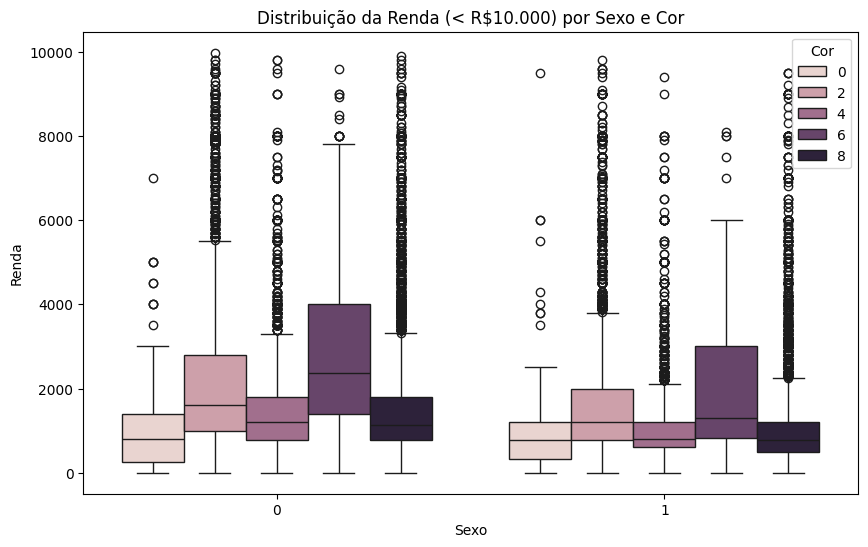

In [85]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_filtrado,
    x='Sexo',
    y='Renda',
    hue='Cor'
)

plt.title('Distribuição da Renda (< R$10.000) por Sexo e Cor')
plt.show()

> ### Conclusões

O boxplot evidencia diferenças significativas de rendimento segundo sexo e cor. Observa-se que homens apresentam medianas superiores às mulheres, e indivíduos brancos possuem rendimentos mais elevados em ambos os sexos. Além disso, homens brancos apresentam maior dispersão e mais valores extremos, indicando maior desigualdade interna. Já mulheres não brancas concentram-se nas faixas mais baixas de renda, com menor variabilidade. Esses resultados reforçam a presença de desigualdades socioeconômicas associadas ao sexo e à cor.

# <font color="red">DESAFIO<font>
### Qual percentual de pessoas de nosso <i>dataset</i> ganham um salário mínimo (R$ 788,00) ou menos?
#### <font color='red'>Utilize a função <i>percentileofscore()</i> do <i>scipy</i> para realizar estas análises.</font>
#### Mais informações: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.percentileofscore.html


In [86]:
from scipy import stats



### Qual o valor máximo ganho por 99% das pessoas de nosso <i>dataset</i>?
#### <font color='red'>Utilize o método <i>quantile()</i> do <i>pandas</i> para realizar estas análises.</font>

In [91]:
df['Renda'] = pd.to_numeric(df['Renda'], errors='coerce')

df.Renda.quantile(0.99)

np.float64(15000.0)

### Obtenha a média, mediana, valor máximo e desvio-padrão da variável RENDA segundo ANOS DE ESTUDO e SEXO
#### <font color='blue'>Destaque os pontos mais importante que você observa nas tabulações</font>
#### <font color='red'>O parâmento <i>aggfunc</i> da função <i>crosstab()</i> pode receber uma lista de funções. Exemplo: <i>aggfunc = ['mean', 'median', 'max', 'std']</i></font>

In [95]:
df['Renda'] = pd.to_numeric(df['Renda'], errors='coerce')

In [98]:
pd.crosstab (
    index=df['Anos de Estudo'],
    columns=df['Sexo'],
    values=df['Renda'],
    aggfunc=['mean', 'median', 'max', 'std']
)

mean               median               max            \
Sexo                      0            1       0       1         0         1   
Anos de Estudo                                                                 
1                799.494638   516.201748   700.0   390.0   30000.0   10000.0   
2                895.629047   492.771987   788.0   400.0   30000.0    2000.0   
3                931.178986   529.911638   788.0   450.0   40000.0    4000.0   
4               1109.203862   546.853916   800.0   500.0   80000.0    3500.0   
5               1302.329283   704.279111  1000.0   788.0   50000.0   10000.0   
6               1338.653218   781.389776  1045.0   788.0   35000.0    8000.0   
7               1448.875419   833.732824  1200.0   788.0   25000.0    6000.0   
8               1465.497940   830.751004  1200.0   788.0   40000.0    9000.0   
9               1639.396667   933.615351  1300.0   800.0   30000.0   18000.0   
10              1508.038850   868.021700  1200.0   788.0   60000.0   20000.0   
11              1731.270847   925.919225  1218.0   800.0   45000.0    6000.0   
12              2117.060504  1286.790889  1500.0  1000.0  200000.0  100000.0   
13              2470.330776  1682.313725  1800.0  1200.0   30000.0  120000.0   
14              3195.099154  1911.730047  2400.0  1300.0   25000.0   20000.0   
15              3706.620269  2226.460457  2500.0  1600.0   50000.0   20000.0   
16              6134.279790  3899.513231  4000.0  2800.0  200000.0  100000.0   
17              1295.761905   798.174419  1200.0   788.0    7000.0    3000.0   

                        std               
Sexo                      0            1  
Anos de Estudo                            
1               1023.904884   639.311534  
2               1331.950552   425.291842  
3               1435.173827   498.234168  
4               2143.800133   424.124446  
5               1419.821787   629.553397  
6               1484.650587   635.782641  
7               1476.628602   574.547028  
8               1419.708673   602.038029  
9               1515.583715   896.781213  
10              2137.664774   973.221652  
11              2078.609734   620.611907  
12              2676.538942  1819.040417  
13              2268.081538  4851.833513  
14              2797.116800  2053.789771  
15              3987.214974  2064.083336  
16              7447.613594  4212.770709  
17               979.648745   459.985964

### Construa um box plot da variável RENDA segundo ANOS DE ESTUDO e SEXO
#### <font color='blue'>É possível verificar algum comportamento diferenciado no rendimento entre os grupos de pessoas analisados? Avalie o gráfico e destaque os pontos mais importantes.</font>
#### <font color='red'>1º - Utilize somente as informações de pessoas com renda abaixo de R$ 10.000</font>
#### <font color='red'>2º - Utilize a variável IDADE para identificar se a desigualdade se verifica para pessoas de mesma idade. Exemplo: <i>data=dados.query('Renda < 10000 and Idade == 40')</i> ou <i>data=dados.query('Renda < 10000 and Idade == 50')</i></font>
#### <font color='red'>3º - Para incluir uma terceira variável na construção de um boxplot utilize o parâmetro <i>hue</i> e indique a variável que quer incluir na subdivisão.</font>
#### Mais informações: https://seaborn.pydata.org/generated/seaborn.boxplot.html

In [103]:
df['Renda'] = pd.to_numeric(df['Renda'], errors='coerce')
df['Idade'] = pd.to_numeric(df['Idade'], errors='coerce')


In [104]:
df_filtrado = df.query('Renda < 10000 and Idade == 40')


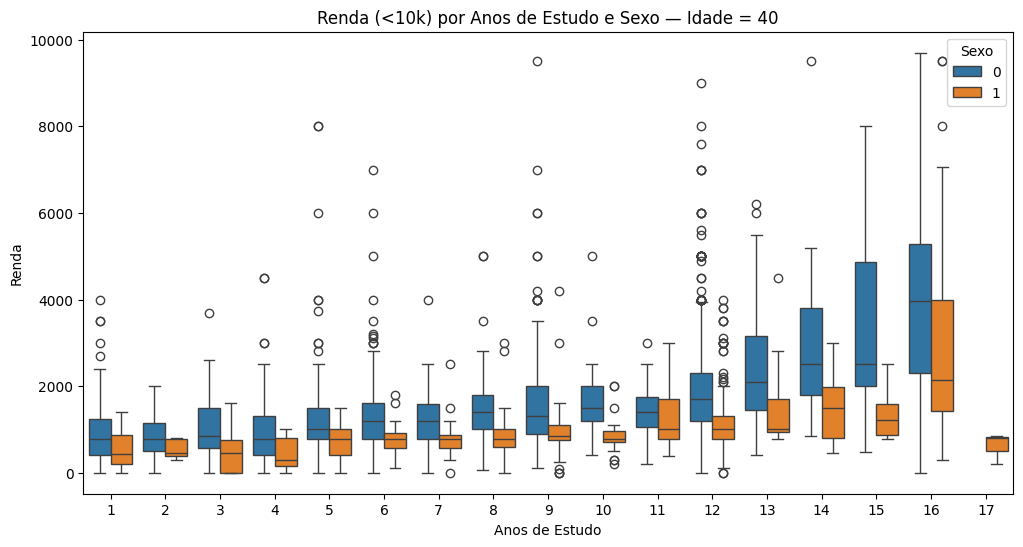

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_filtrado,
    x='Anos de Estudo',
    y='Renda',
    hue='Sexo'
)

plt.title('Renda (<10k) por Anos de Estudo e Sexo — Idade = 40')
plt.show()

> ### Conclusões

O boxplot evidencia que, mesmo controlando por idade e restringindo a renda abaixo de R$10.000, observa-se aumento consistente da renda com os anos de estudo. Em todos os níveis educacionais, homens apresentam medianas superiores às mulheres, indicando desigualdade salarial persistente mesmo entre indivíduos da mesma idade e escolaridade. Essa diferença torna-se mais pronunciada nos níveis mais altos de estudo. Além disso, mulheres apresentam menor dispersão e concentração em faixas salariais mais baixas, sugerindo um teto de renda.

### Obtenha a média, mediana, valor máximo e desvio-padrão da variável RENDA segundo as UNIDADES DA FEDERAÇÃO
#### <font color='blue'>Destaque os pontos mais importante que você observa nas tabulações</font>
#### <font color='red'>Utilize o método <i>groupby()</i> do <i>pandas</i> juntamente com o método <i>agg()</i> para contruir a tabulação. O método <i>agg()</i> pode receber um dicionário especificando qual coluna do DataFrame deve ser utilizada e qual lista de funções estatísticas queremos obter, por exemplo: <i>dados.groupby(['UF']).agg({'Renda': ['mean', 'median', 'max', 'std']})</i></font>

In [106]:
df['Renda'] = pd.to_numeric(df['Renda'], errors='coerce')

In [107]:
tabela_uf = df.groupby('UF').agg({
    'Renda': ['mean', 'median', 'max', 'std']
})

tabela_uf


Renda                               
           mean  median       max          std
UF                                            
11  1789.761223  1200.0   50000.0  2406.161161
12  1506.091782   900.0   30000.0  2276.233415
13  1445.130100   900.0   22000.0  1757.935591
14  1783.588889  1000.0   20000.0  2079.659238
15  1399.076871   850.0   50000.0  2053.779555
16  1861.353516  1200.0   15580.0  2020.688632
17  1771.094946  1000.0   60000.0  2934.590741
21  1019.432009   700.0   30000.0  1887.816905
22  1074.550784   750.0   40000.0  2373.355726
23  1255.403692   789.0   25000.0  1821.963536
24  1344.721480   800.0   15500.0  1651.805500
25  1293.370487   788.0   30000.0  1950.272431
26  1527.079319   900.0   50000.0  2389.622497
27  1144.552602   788.0   11000.0  1237.856197
28  1109.111111   788.0   16000.0  1478.997878
29  1429.645094   800.0  200000.0  3507.917248
31  2056.432084  1200.0  100000.0  3584.721547
32  2026.383852  1274.0  100000.0  3513.846868
33  2496.403168  1400.0  200000.0  5214.583518
35  2638.104986  1600.0   80000.0  3503.777366
41  2493.870753  1500.0  200000.0  4302.937995
42  2470.854945  1800.0   80000.0  3137.651112
43  2315.158336  1500.0   35000.0  2913.335783
50  2262.604167  1500.0   42000.0  3031.419122
51  2130.652778  1500.0   35000.0  2542.630178
52  1994.580794  1500.0   30000.0  2221.933065
53  4241.954722  2000.0  100000.0  5550.463338

### Construa um box plot da variável RENDA segundo as UNIDADES DA FEDERAÇÃO
#### <font color='blue'>É possível verificar algum comportamento diferenciado no rendimento entre os grupos analisados? Avalie o gráfico e destaque os pontos mais importantes.</font>
#### <font color='red'>1º - Utilize somente as informações de pessoas com renda abaixo de R$ 10.000</font>

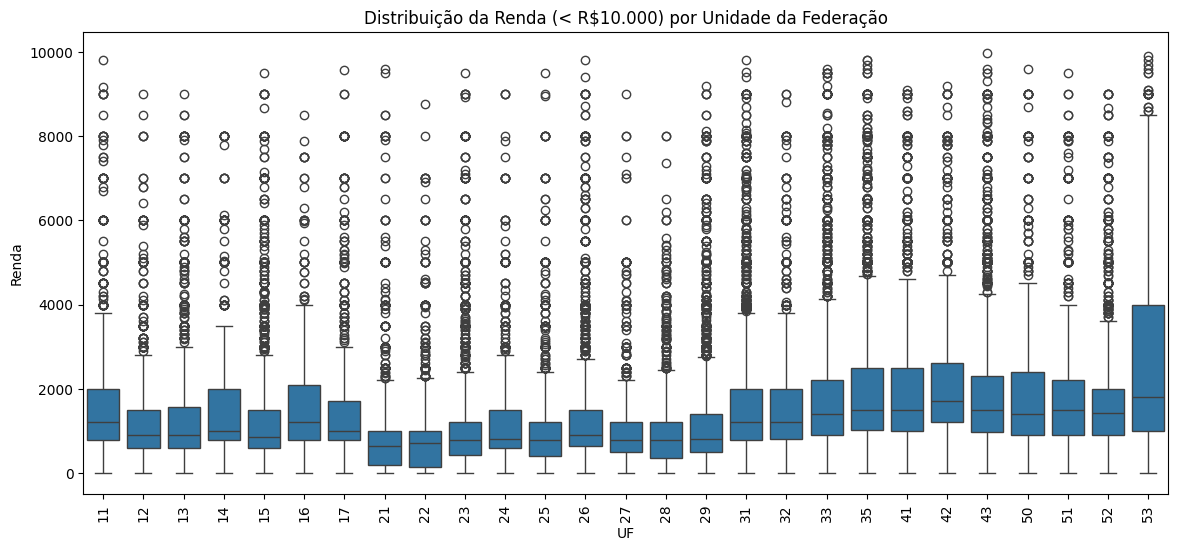

In [109]:
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df_filtrado,
    x='UF',
    y='Renda'
)

plt.xticks(rotation=90)
plt.title('Distribuição da Renda (< R$10.000) por Unidade da Federação')
plt.show()



> ### Conclusões

O boxplot evidencia forte desigualdade regional de renda. Estados do Sudeste, Sul e o Distrito Federal apresentam medianas mais elevadas e maior dispersão, indicando presença de rendas relativamente maiores e maior heterogeneidade interna. Em contraste, estados das regiões Norte e Nordeste concentram-se em faixas mais baixas de renda, com menor variabilidade. Mesmo restringindo a renda abaixo de R$10.000, as diferenças regionais permanecem evidentes, reforçando o caráter estrutural da desigualdade.